# SWOOSH and Ozone sonde O3 Comparison

SWOOSH comined ACE and MLS O3 data wre compared against NOAA GML ozone sonde data (from Boulder). 

To do this, ozone sonde EqLat data is generated from ERA5 and MERRA-2. 
This was done on thr HPC Orion, and combined data sets are in data/ozonesonde

In [742]:
import sys
import os
import gc
import re
import io
import time
import requests
from datetime import datetime
import pathlib
from pathlib import Path
from glob import glob
from datetime import timedelta

# Data Analysis & Science
import numpy as np
import pandas as pd
import xarray as xr
import xesmf as xe
from bs4 import BeautifulSoup
import h5py 
from scipy import stats
from scipy.interpolate import RegularGridInterpolator

# Visualization
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
%matplotlib inline

In [743]:
ozonesonde_dir = os.path.join(
    pathlib.Path.home(),
    'Documents',
    'GitHub',
    'eqlat_HPC',
    'data',
    'ozonesonde'
)

### Merge all single profiles into one large one

In [744]:
csv_files = sorted(glob(os.path.join(ozonesonde_dir, '*.csv')))

dfs = []
for f in csv_files:
    df = pd.read_csv(f)
    df['sonde_file'] = os.path.basename(f)
    dfs.append(df)

ozonesonde_df = pd.concat(dfs, ignore_index=True, sort=False)
ozonesonde_df['DATETIME GMT'] = pd.to_datetime(ozonesonde_df['DATETIME GMT'], errors='coerce')

print(f'{len(csv_files)} files -> {ozonesonde_df.shape[0]} rows, {ozonesonde_df.shape[1]} columns')
ozonesonde_df.columns

341 files -> 3098634 rows, 87 columns


Index(['Time [min]', 'Time Sec [sec]', 'Time GMT [hh:mm:ss GMT]',
       'Press [hPa]', 'Praw [hPa]', 'Alt [km]', 'Tcorr [deg C]',
       'Temp [deg C]', 'Traw [deg C]', 'Theta [K]', 'RH [%]', 'RHraw [%]',
       'TFp V [deg C]', 'RS H2O Mr [ppmv]', 'IPW V [mm]', 'TVaisI [deg C]',
       'RS Bat [V]', 'RS P Temp [deg C]', 'RS U Temp [deg C]',
       'Rise Rate [m/s]', 'O3 Cell I [uA]', 'O3 P [mPa]', 'O3 Mr [ppmv]',
       'T Pump [deg C]', 'T Pump Raw [deg C]', 'O3Bat [V]', 'I Pump [mA]',
       'Total Column O3 [DU]', 'Total w/ Extrap O3 [DU]',
       'Total w/ SBUV O3 [DU]', 'O3 Current Uncert [%]',
       'O3 Conversion Uncert [%]', 'O3 Flowrate Uncert [%]',
       'O3 Pump Temp Uncert [%]', 'O3 Total Uncert [%]', 'GPS lat [deg]',
       'GPS lon [deg]', 'GPS alt [km]', 'GPS sats []',
       'GPS Time [hh:mm:ss GMT]', 'GPS Press [mb]', 'GPS Heading [deg]',
       'GPS Elev Angle [deg]', 'Wind Speed [m/s]', 'Wind Dir [deg]',
       'DATETIME GMT', 'launch_lat', 'launch_lon', 'eqlat_E

### Bin ozonesonde O3 onto an EqLat × Θ grid (ERA5 and MERRA-2 EqLat)

In [745]:
def bin_o3_eqlat(df, eqlat_col, o3_col='O3 Mr [ppmv]', bin_col='theta_K',
                         eqlat_bins=np.arange(-90, 91, 10), bins=np.arange(300, 2000, 50),
                         log_bins=False, min_count=3):
    """Average Ozone sonde onto an equivalent-latitude x vertical-coordinate grid.

    Set log_bins=True for a log-spaced vertical coordinate (e.g. pressure,
    ordered increasing since pd.cut requires monotonically increasing bins),
    matching the SWOOSH pressure binning: bin centers then use the geometric
    mean instead of the arithmetic mean, and the output dim is named 'pressure'.

    Bins with fewer than min_count observations are left as NaN.
    """
    eqlat_centers = 0.5 * (eqlat_bins[:-1] + eqlat_bins[1:])
    theta_centers = (np.sqrt(bins[:-1] * bins[1:]) if log_bins
                      else 0.5 * (bins[:-1] + bins[1:]))

    valid = df[[eqlat_col, bin_col, o3_col]].dropna()

    eqlat_idx = pd.cut(valid[eqlat_col], eqlat_bins, labels=False)
    theta_idx = pd.cut(valid[bin_col], bins, labels=False)

    shape = (len(eqlat_centers), len(theta_centers))
    #binned = np.full((len(eqlat_centers), len(theta_centers)), np.nan)
    mean_binned = np.full(shape, np.nan)
    std_binned = np.full(shape, np.nan)
    count_binned = np.zeros(shape, dtype=int)
    grouped = valid.groupby([eqlat_idx, theta_idx], observed=True)[o3_col].agg(['mean', 'std', 'count'])

    for (i, j), row in grouped.iterrows():
        count_binned[int(i), int(j)] = row['count']
        if row['count'] >= min_count:
            mean_binned[int(i), int(j)] = row['mean']
            std_binned[int(i), int(j)] = row['std']

    vert_dim = 'pressure' if log_bins else 'theta'
    dims = ['eqlat', vert_dim]
    coords = {'eqlat': eqlat_centers, vert_dim: theta_centers}
    return xr.Dataset(
        {
            'mean': (dims, mean_binned),
            'std': (dims, std_binned),
            'count': (dims, count_binned),
        },
        coords=coords,
        attrs={'name': o3_col.strip()},
    )


SEASON_MAP = {12: 'DJF', 1: 'DJF', 2: 'DJF',
              3: 'MAM', 4: 'MAM', 5: 'MAM',
              6: 'JJA', 7: 'JJA', 8: 'JJA',
              9: 'SON', 10: 'SON', 11: 'SON'}


def bin_o3_eqlat_theta_seasonal(df, eqlat_col, o3_col='O3 Mr [ppmv]', bin_col='theta_K',
                                  time_col='DATETIME GMT',
                                  eqlat_bins=np.arange(-90, 91, 10), bins=np.arange(300, 1400, 50),
                                  log_bins=False):
    """Same as bin_o3_eqlat, but split into DJF/MAM/JJA/SON before binning.

    Set log_bins=True for a log-spaced vertical coordinate like pressure,
    same as bin_o3_eqlat.
    """
    season = pd.to_datetime(df[time_col]).dt.month.map(SEASON_MAP)

    binned_per_season = {
        s: bin_o3_eqlat(df[season == s], eqlat_col, o3_col, bin_col, eqlat_bins, bins, log_bins)
        for s in ['DJF', 'MAM', 'JJA', 'SON']
    }
    return xr.concat(binned_per_season.values(), dim=pd.Index(binned_per_season.keys(), name='season'))

In [746]:
o3_era5_eqlat_theta_seasonal = bin_o3_eqlat_theta_seasonal(ozonesonde_df, 'eqlat_ERA5_piecewise')
o3_merra2_eqlat_theta_seasonal = bin_o3_eqlat_theta_seasonal(ozonesonde_df, 'eqlat_MERRA2_piecewise')

In [747]:
o3_era5_eqlat_theta_seasonal

<xarray.Dataset> Size: 37kB
Dimensions:  (season: 4, eqlat: 18, theta: 21)
Coordinates:
  * season   (season) StringDType(na_object=nan) 64B 'DJF' 'MAM' 'JJA' 'SON'
  * eqlat    (eqlat) float64 144B -85.0 -75.0 -65.0 -55.0 ... 65.0 75.0 85.0
  * theta    (theta) float64 168B 325.0 375.0 425.0 ... 1.275e+03 1.325e+03
Data variables:
    mean     (season, eqlat, theta) float64 12kB nan nan nan nan ... nan nan nan
    std      (season, eqlat, theta) float64 12kB nan nan nan nan ... nan nan nan
    count    (season, eqlat, theta) int64 12kB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
Attributes:
    name:     O3 Mr [ppmv]

### SWOOSH O3 data

In [748]:
swoosh_th = xr.open_dataset('/Users/jesswein/Documents/GitHub/eqlat_HPC/data/satellite/swoosh-v02.72-198401-202602-lattheta-10deg-L33.nc')
#swoosh_press = xr.open_dataset('/Users/jesswein/Documents/GitHub/eqlat_HPC/data/satellite/swoosh-v02.72-198401-202602-latpress-5deg-L31.nc')

/Users/jesswein/miniconda3/envs/aero_fix/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'aceh2on' has non-conforming 'missing_value' np.float32(nan) defined, dropping 'missing_value' entirely.
  var = coder.decode(var, name=name)
/Users/jesswein/miniconda3/envs/aero_fix/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'aceh2oneq' has non-conforming 'missing_value' np.float32(nan) defined, dropping 'missing_value' entirely.
  var = coder.decode(var, name=name)
/Users/jesswein/miniconda3/envs/aero_fix/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'acen2on' has non-conforming 'missing_value' np.float32(nan) defined, dropping 'missing_value' entirely.
  var = coder.decode(var, name=name)
/Users/jesswein/miniconda3/envs/aero_fix/lib/python3.12/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'acen2oneq' has non-conforming 'missing_value' np.float32(na

In [749]:
swoosh_th_recent = swoosh_th.sel(time=slice('2010', '2025'))

### Bin SWOOSH O3 onto the same Θ grid (mean, std, count)

In [750]:
def bin_theta_profile(o3_profile, theta_profile, theta_bins):
    """Average one (level) O3 profile into fixed potential-temperature bins."""
    bin_idx = np.digitize(theta_profile, theta_bins) - 1
    binned = np.full(len(theta_bins) - 1, np.nan)
    for i in range(len(theta_bins) - 1):
        mask = bin_idx == i
        if mask.any():
            binned[i] = np.nanmean(o3_profile[mask])
    return binned


theta_bins = np.arange(300, 1400, 50)          # K, bin edges -- same grid as the ozonesonde binning above
theta_centers = 0.5 * (theta_bins[:-1] + theta_bins[1:])  # bin midpoints, used as the new theta coordinate

# combinedo3q holds fill/error values as huge numbers (both negative, e.g. -18000 ppmv,
# and positive, up to ~1e7 ppmv) instead of NaN -- clip to the physically plausible
# stratospheric O3 range so they don't skew the bin averages below
swoosh_o3_valid = swoosh_th_recent['combinedo3q'].where(
    (swoosh_th_recent['combinedo3q'] >= 0) & (swoosh_th_recent['combinedo3q'] <= 20)
)

# swoosh_th_recent['level'] is fixed (not time/lat-dependent), so apply_ufunc broadcasts
# it against combinedo3q automatically, replacing the native 33 (irregular) levels
# with the uniform theta_bins grid used for the ozonesonde comparison
swoosh_o3_theta = xr.apply_ufunc(
    bin_theta_profile,
    swoosh_o3_valid,
    swoosh_th_recent['level'],
    input_core_dims=[['level'], ['level']],
    output_core_dims=[['theta']],
    exclude_dims={'level'},
    vectorize=True,
    kwargs={'theta_bins': theta_bins},
)
swoosh_o3_theta = swoosh_o3_theta.assign_coords(theta=theta_centers)
swoosh_o3_theta.name = 'combinedo3q'
swoosh_o3_theta

/var/folders/_x/vj_l8lbd6739nqm7v3yptrmw0010ht/T/ipykernel_78535/821294081.py:8: RuntimeWarning: Mean of empty slice
  binned[i] = np.nanmean(o3_profile[mask])


<xarray.DataArray 'combinedo3q' (time: 192, lat: 18, theta: 21)> Size: 581kB
array([[[0.19666231, 0.31296471, 0.58851558, ..., 5.12861633,
         5.07476759,        nan],
        [0.19172721, 0.3080534 , 0.57816005, ..., 5.02264977,
         4.90593004,        nan],
        [0.44520697, 0.30177146, 0.55578321, ..., 5.50204325,
         5.29682159,        nan],
        ...,
        [0.76585066, 0.81257713, 1.62625241, ..., 5.21897221,
         5.09781551,        nan],
        [0.24875337, 0.88704747, 1.80358553, ..., 4.89319372,
         4.75646305,        nan],
        [0.27755088, 0.93524963, 1.88466871, ..., 4.72423267,
         4.57802773,        nan]],

       [[0.18018623, 0.30892688, 0.65229762, ..., 4.69427729,
         4.75552177,        nan],
        [0.1712807 , 0.30041319, 0.61822933, ..., 4.86995888,
         4.84205246,        nan],
        [0.16043283, 0.28033891, 0.58150709, ..., 5.72396755,
         5.57472229,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ..., 1.74314713,
         1.64510787,        nan],
        [0.1728619 , 0.52568543, 1.29014373, ..., 6.11889648,
         6.03340149,        nan]],

       [[0.18427172, 0.36187145, 0.66909564, ..., 5.58319283,
         5.45737505,        nan],
        [0.18541515, 0.35786554, 0.64725435, ..., 5.42072344,
         5.24855995,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [0.17094436, 0.6188153 , 1.33079815, ..., 5.86210489,
         5.71673679,        nan],
        [0.19214912, 0.68612969, 1.49572766, ..., 5.85418606,
         5.69992542,        nan],
        [0.20036903, 0.6992836 , 1.54330134, ..., 5.86403227,
         5.7291255 ,        nan]]], shape=(192, 18, 21))
Coordinates:
  * time     (time) datetime64[ns] 2kB 2010-01-16T12:00:00.000040192 ... 2025...
  * lat      (lat) float32 72B -85.0 -75.0 -65.0 -55.0 ... 55.0 65.0 75.0 85.0
  * theta    (theta) float64 168B 325.0 375.0 425.0 ... 1.275e+03 1.325e+03
Attributes:
    long_name:   Combined O3
    grid_type:   geographic
    _Fillvalue:  nan
    units:       ppmv

In [751]:
swoosh_o3_th_seasonal = swoosh_o3_theta.groupby('time.season').mean('time', skipna=True)
swoosh_o3_th_seasonal

<xarray.DataArray 'combinedo3q' (season: 4, lat: 18, theta: 21)> Size: 12kB
array([[[0.17662166, 0.29991948, 0.56007837, ..., 5.12321315,
         5.08512632,        nan],
        [0.51239782, 0.58045922, 0.84162817, ..., 5.40360103,
         5.29374665,        nan],
        [0.47840171, 0.2919954 , 0.56133818, ..., 5.61252188,
         5.40178069,        nan],
        ...,
        [0.55063967, 0.74601683, 1.47960438, ..., 5.77707839,
         5.66865796,        nan],
        [0.2641364 , 0.84503407, 1.69958389, ..., 5.40842156,
         5.28495825,        nan],
        [0.32008634, 0.88730903, 1.79202845, ..., 5.18932391,
         5.07109486,        nan]],

       [[0.21457516, 1.07770099, 2.26834854, ..., 4.22929043,
         4.13978429,        nan],
        [0.2081118 , 0.99944471, 2.11633204, ..., 4.24205061,
         4.17422064,        nan],
        [0.29107107, 0.78125193, 1.64893831, ..., 5.00634539,
         4.9375111 ,        nan],
...
        [0.41583553, 0.72606175, 1.18823637, ..., 6.82168671,
         6.6168353 ,        nan],
        [0.7011183 , 0.96562638, 1.46545638, ..., 6.32802392,
         6.19390024,        nan],
        [0.51438346, 0.81426313, 1.33181762, ..., 5.75427601,
         5.65664841,        nan]],

       [[0.19990892, 0.33067861, 0.48245933, ..., 4.91928561,
         4.83045606,        nan],
        [0.18543736, 0.32823204, 0.48529771, ..., 5.12388532,
         4.99599865,        nan],
        [0.27838561, 0.37693311, 0.69210046, ..., 6.01215843,
         5.83020189,        nan],
        ...,
        [0.5801887 , 0.40406551, 0.8960946 , ..., 6.13293081,
         6.04079356,        nan],
        [0.42295912, 0.45098945, 1.02426306, ..., 5.12887748,
         5.09091957,        nan],
        [0.56048389, 0.47278   , 1.08175426, ..., 4.52069634,
         4.50920028,        nan]]], shape=(4, 18, 21))
Coordinates:
  * season   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
  * lat      (lat) float32 72B -85.0 -75.0 -65.0 -55.0 ... 55.0 65.0 75.0 85.0
  * theta    (theta) float64 168B 325.0 375.0 425.0 ... 1.275e+03 1.325e+03
Attributes:
    long_name:   Combined O3
    grid_type:   geographic
    _Fillvalue:  nan
    units:       ppmv

In [752]:
# Bin combinedo3stddev and combinedo3n onto the same theta grid as combinedo3q,
# reusing bin_theta_profile/theta_bins/theta_centers from above. combinedo3stddev
# has the same huge fill values as combinedo3q, so mask it the same way (and also
# require combinedo3q to be valid there, since a stddev/n is only meaningful where
# the mean itself is valid); combinedo3n only needs the combinedo3q validity mask.
swoosh_o3stddev_valid = swoosh_th_recent['combinedo3stddev'].where(
    (swoosh_th_recent['combinedo3stddev'] >= 0) & (swoosh_th_recent['combinedo3stddev'] <= 20)
    & swoosh_o3_valid.notnull()
)
swoosh_o3n_valid = swoosh_th_recent['combinedo3n'].where(swoosh_o3_valid.notnull())

swoosh_o3stddev_theta = xr.apply_ufunc(
    bin_theta_profile,
    swoosh_o3stddev_valid,
    swoosh_th_recent['level'],
    input_core_dims=[['level'], ['level']],
    output_core_dims=[['theta']],
    exclude_dims={'level'},
    vectorize=True,
    kwargs={'theta_bins': theta_bins},
)
swoosh_o3stddev_theta = swoosh_o3stddev_theta.assign_coords(theta=theta_centers)
swoosh_o3stddev_theta.name = 'combinedo3stddev'

swoosh_o3n_theta = xr.apply_ufunc(
    bin_theta_profile,
    swoosh_o3n_valid,
    swoosh_th_recent['level'],
    input_core_dims=[['level'], ['level']],
    output_core_dims=[['theta']],
    exclude_dims={'level'},
    vectorize=True,
    kwargs={'theta_bins': theta_bins},
)
swoosh_o3n_theta = swoosh_o3n_theta.assign_coords(theta=theta_centers)
swoosh_o3n_theta.name = 'combinedo3n'

swoosh_o3stddev_th_seasonal = swoosh_o3stddev_theta.groupby('time.season').mean('time', skipna=True)
swoosh_o3n_th_seasonal = swoosh_o3n_theta.groupby('time.season').mean('time', skipna=True)

# Bundle mean/std/count together, matching the o3_era5/merra2_eqlat_theta_seasonal
# Dataset layout so relative std and count can be computed/plotted the same way.
swoosh_o3_theta_seasonal = xr.Dataset({
    'mean': swoosh_o3_th_seasonal,
    'std': swoosh_o3stddev_th_seasonal,
    'count': swoosh_o3n_th_seasonal,
})
swoosh_o3_theta_seasonal

/var/folders/_x/vj_l8lbd6739nqm7v3yptrmw0010ht/T/ipykernel_78535/821294081.py:8: RuntimeWarning: Mean of empty slice
  binned[i] = np.nanmean(o3_profile[mask])


<xarray.Dataset> Size: 37kB
Dimensions:  (lat: 18, theta: 21, season: 4)
Coordinates:
  * lat      (lat) float32 72B -85.0 -75.0 -65.0 -55.0 ... 55.0 65.0 75.0 85.0
  * theta    (theta) float64 168B 325.0 375.0 425.0 ... 1.275e+03 1.325e+03
  * season   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
Data variables:
    mean     (season, lat, theta) float64 12kB 0.1766 0.2999 ... 4.509 nan
    std      (season, lat, theta) float64 12kB 0.02819 0.03607 ... 0.8673 nan
    count    (season, lat, theta) float64 12kB 1.885e+03 2.992e+03 ... nan

### Comparison plots

In [753]:
def plot_swoosh_ozonesonde_comparison(season):
    """Compare SWOOSH and AirCore (ERA5/MERRA2 EqLat) N2O, Northern Hemisphere only, one season.
    """

    swoosh_data = swoosh_o3_th_seasonal
    era5_data = o3_era5_eqlat_theta_seasonal
    merra2_data = o3_merra2_eqlat_theta_seasonal
    vert_dim = 'theta'
    ylabel = r'$\Theta$ [K]'

    swoosh_nh = swoosh_data.sel(season=season, lat=slice(0, 90))
    era5_nh = era5_data.sel(season=season, eqlat=slice(0, 90))['mean']
    merra2_nh = merra2_data.sel(season=season, eqlat=slice(0, 90))['mean']

    vmax = 10 #max(swoosh_nh.max().item(), era5_nh.max().item(), merra2_nh.max().item())

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

    swoosh_nh.plot(ax=axes[0], x='lat', y=vert_dim, vmin=0, vmax=vmax, add_colorbar=False)
    axes[0].set_title(f'SWOOSH ({season})')
    axes[0].set_xlabel('Latitude [°]')
    axes[0].set_ylabel(ylabel)

    era5_nh.plot(ax=axes[1], x='eqlat', y=vert_dim, vmin=0, vmax=vmax, add_colorbar=False)
    axes[1].set_title(f'Ozone sonde, ERA5 EqLat ({season})')
    axes[1].set_xlabel('Equivalent Latitude [°]')
    axes[1].set_ylabel('')

    im = merra2_nh.plot(ax=axes[2], x='eqlat', y=vert_dim, vmin=0, vmax=vmax, add_colorbar=False)
    axes[2].set_title(f'Ozone sonde, MERRA-2 EqLat ({season})')
    axes[2].set_xlabel('Equivalent Latitude [°]')
    axes[2].set_ylabel('')


    for ax in axes:
        ax.set_ylim(350, 1000)

    fig.colorbar(im, ax=axes, label='$O_3$ [ppm]', shrink=0.8)
    return fig, axes

In [754]:
def plot_swoosh_ozonesonde_diff(season):
    """Plot AirCore-minus-SWOOSH N2O differences (ERA5, MERRA2, ERA5 vs MERRA2), NH only, one season.

    vertical: 'theta' or 'pressure' - which vertical binning of the data to use.
    """

    swoosh_data = swoosh_o3_th_seasonal
    era5_data = o3_era5_eqlat_theta_seasonal
    merra2_data = o3_merra2_eqlat_theta_seasonal
    vert_dim = 'theta'
    ylabel = r'$\Theta$ [K]'

    swoosh_nh = swoosh_data.sel(season=season, lat=slice(0, 90))
    era5_nh = era5_data.sel(season=season, eqlat=slice(0, 90))['mean'].rename({'eqlat': 'lat'})
    merra2_nh = merra2_data.sel(season=season, eqlat=slice(0, 90))['mean'].rename({'eqlat': 'lat'})


    diff_era5_swoosh = era5_nh - swoosh_nh
    diff_merra2_swoosh = merra2_nh - swoosh_nh
    diff_era5_merra2 = era5_nh - merra2_nh

    vabs = max(abs(diff_era5_swoosh).max().item(),
               abs(diff_merra2_swoosh).max().item(),
               abs(diff_era5_merra2).max().item())

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

    diff_era5_swoosh.plot(ax=axes[0], x='lat', y=vert_dim, cmap='RdBu_r', vmin=-vabs, vmax=vabs, add_colorbar=False)
    axes[0].set_title(f'Sonde (ERA5) − SWOOSH ({season})')
    axes[0].set_xlabel('Latitude / EqLat [°]')
    axes[0].set_ylabel(ylabel)

    diff_merra2_swoosh.plot(ax=axes[1], x='lat', y=vert_dim, cmap='RdBu_r', vmin=-vabs, vmax=vabs, add_colorbar=False)
    axes[1].set_title(f'Sonde (MERRA-2) − SWOOSH ({season})')
    axes[1].set_xlabel('Latitude / EqLat [°]')
    axes[1].set_ylabel('')

    im = diff_era5_merra2.plot(ax=axes[2], x='lat', y=vert_dim, cmap='RdBu_r', vmin=-vabs, vmax=vabs, add_colorbar=False)
    axes[2].set_title(f'Sonde (ERA5) − Sonde (MERRA-2) ({season})')
    axes[2].set_xlabel('Latitude / EqLat [°]')
    axes[2].set_ylabel('')


    for ax in axes:
        ax.set_ylim(350, 1000)

    fig.colorbar(im, ax=axes, label='Δ$O_3$ [ppm]', shrink=0.8)
    return fig, axes, (diff_era5_swoosh, diff_merra2_swoosh, diff_era5_merra2)

In [773]:
def invert_swoosh_lat(swoosh_profile):
    """Invert a single-theta SWOOSH O3(lat) profile (NH only) to get lat(O3).

    Returns (o3_sorted, lat_sorted) suitable for np.interp: NaNs are dropped
    and the profile is sorted by O3 value so np.interp always sees an
    increasing x-array. Mildly non-monotonic profiles are tolerated but not
    corrected for -- see plot_swoosh_ozonesonde_delta_lat docstring.
    """
    valid = swoosh_profile.notnull()
    o3_vals = swoosh_profile.where(valid, drop=True).values
    lat_vals = swoosh_profile['lat'].where(valid, drop=True).values
    if len(o3_vals) < 2:
        return None
    order = np.argsort(o3_vals)
    return o3_vals[order], lat_vals[order]


def compute_swoosh_matched_delta_lat(eqlat_data, swoosh_data, season):
    """For each (eqlat, theta) sonde bin, find the SWOOSH latitude (same
    season/theta, NH only) whose O3 value matches the sonde bin's O3 mean,
    and return eqlat - matched_lat.

    This re-expresses the sonde/SWOOSH O3 mismatch as an equivalent-latitude
    offset instead of a ppmv difference: it answers "at what real latitude
    would SWOOSH show this same O3 value?". SWOOSH O3(lat) is assumed
    monotonic in the NH; bins outside SWOOSH's O3 range at that theta, or on
    a non-monotonic theta level, are left as NaN rather than guessed at.
    """
    eqlat_nh = eqlat_data.sel(season=season, eqlat=slice(0, 90))['mean']
    swoosh_nh = swoosh_data.sel(season=season, lat=slice(0, 90))

    delta_lat = xr.full_like(eqlat_nh, np.nan)

    for theta in eqlat_nh['theta'].values:
        inverted = invert_swoosh_lat(swoosh_nh.sel(theta=theta))
        if inverted is None:
            continue
        o3_sorted, lat_sorted = inverted
        o3_min, o3_max = o3_sorted[0], o3_sorted[-1]

        targets = eqlat_nh.sel(theta=theta)
        in_range = (targets >= o3_min) & (targets <= o3_max)
        matched_lat = np.interp(targets.values, o3_sorted, lat_sorted)
        delta = targets['eqlat'].values - matched_lat
        delta_lat.loc[dict(theta=theta)] = np.where(in_range.values, delta, np.nan)

    return delta_lat


def plot_swoosh_ozonesonde_delta_lat(season):
    """Plot the O3-equivalent latitude offset between sonde EqLat bins and SWOOSH, NH only, one season.

    For each (eqlat, theta) sonde bin, delta_lat = eqlat - lat_swoosh, where
    lat_swoosh is the latitude at which SWOOSH's O3(lat) profile on that same
    isentrope equals the sonde bin's O3 value (see
    compute_swoosh_matched_delta_lat). Positive delta_lat means the sonde's
    equivalent latitude sits poleward of where SWOOSH would place that O3
    value; negative means equatorward.
    """
    era5_delta = compute_swoosh_matched_delta_lat(o3_era5_eqlat_theta_seasonal, swoosh_o3_th_seasonal, season)
    merra2_delta = compute_swoosh_matched_delta_lat(o3_merra2_eqlat_theta_seasonal, swoosh_o3_th_seasonal, season)

    vabs = max(np.nanmax(np.abs(era5_delta.values)), np.nanmax(np.abs(merra2_delta.values)))
    vert_dim = 'theta'
    ylabel = r'$\Theta$ [K]'

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

    era5_delta.plot(ax=axes[0], x='eqlat', y=vert_dim, cmap='RdBu_r', vmin=-90, vmax=90, add_colorbar=False)
    axes[0].set_title(f'ERA5 EqLat − SWOOSH-matched Lat ({season})')
    axes[0].set_xlabel('Equivalent Latitude [°]')
    axes[0].set_ylabel(ylabel)

    im = merra2_delta.plot(ax=axes[1], x='eqlat', y=vert_dim, cmap='RdBu_r', vmin=-90, vmax=90, add_colorbar=False)
    axes[1].set_title(f'MERRA-2 EqLat − SWOOSH-matched Lat ({season})')
    axes[1].set_xlabel('Equivalent Latitude [°]')
    axes[1].set_ylabel('')

    for ax in axes:
        ax.set_ylim(350, 1000)

    fig.subplots_adjust(wspace=0.3)
    fig.colorbar(im, ax=axes, label='Δ Latitude [°]', shrink=0.8)
    return fig, axes, (era5_delta, merra2_delta)

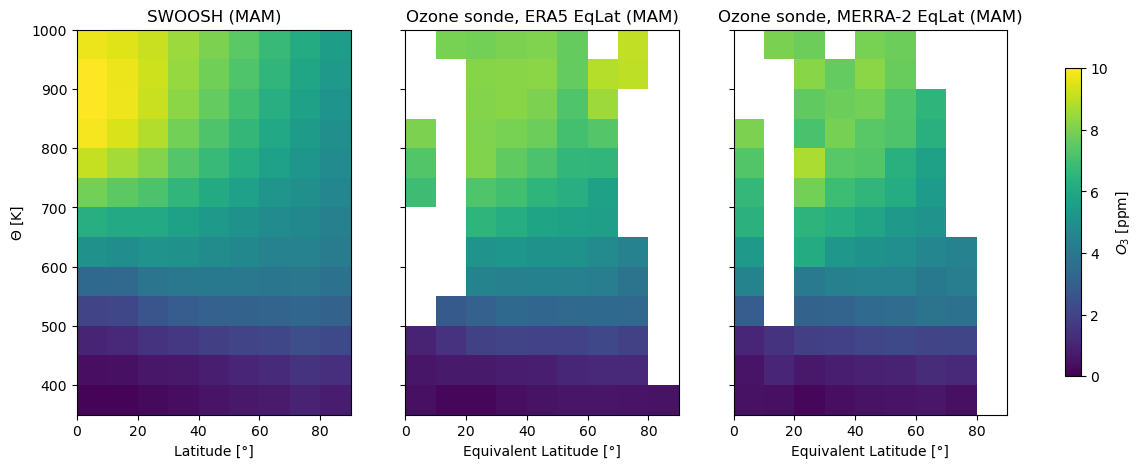

In [780]:
fig, axes = plot_swoosh_ozonesonde_comparison('MAM')

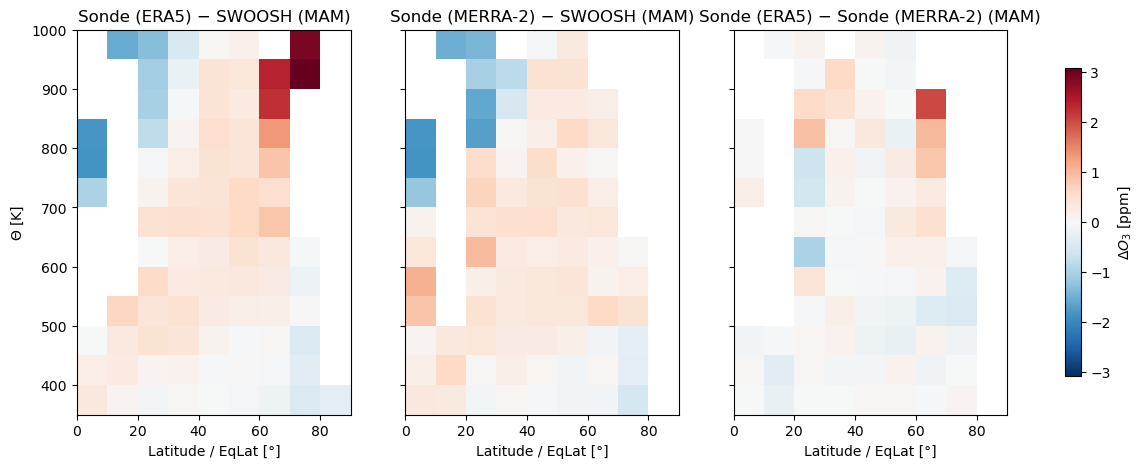

In [781]:
fig, axes, (diff_era5_swoosh, diff_merra2_swoosh, diff_era5_merra2) = plot_swoosh_ozonesonde_diff('MAM')

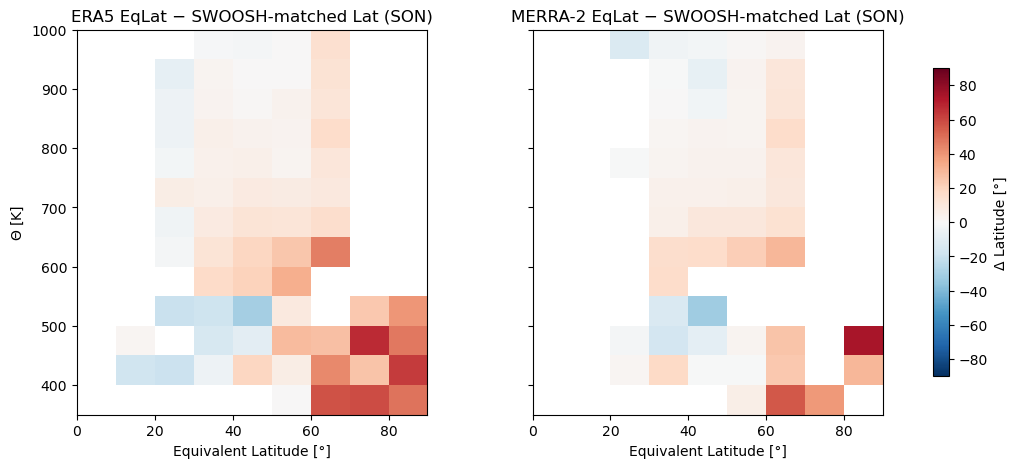

In [786]:
fig, axes, (era5_delta_lat, merra2_delta_lat) = plot_swoosh_ozonesonde_delta_lat('SON')

In [759]:
def plot_swoosh_ozonesonde_std_count(season):
    """Plot per-bin relative std and count for O3 (SWOOSH, ERA5 sonde EqLat, MERRA2 sonde EqLat), NH only, one season.

    Relative std is std / mean (coefficient of variation), expressed as a percentage.
    Two rows (relative std, count) x three columns (SWOOSH, ERA5, MERRA2), same
    layout as plot_swoosh_ozonesonde_comparison. Count uses a log color scale
    since counts span orders of magnitude; relative std uses a linear "traffic
    light" scale (green=low/trustworthy, red=high/noisy), capped at 100% with an
    over-range arrow on the colorbar, since it's a data-quality indicator rather
    than a quantity where log-scale ratios matter.
    """
    from matplotlib.colors import LogNorm

    swoosh_data = swoosh_o3_theta_seasonal
    era5_data = o3_era5_eqlat_theta_seasonal
    merra2_data = o3_merra2_eqlat_theta_seasonal
    vert_dim = 'theta'
    ylabel = r'$\Theta$ [K]'

    swoosh_nh = swoosh_data.sel(season=season, lat=slice(0, 90))
    era5_nh = era5_data.sel(season=season, eqlat=slice(0, 90))
    merra2_nh = merra2_data.sel(season=season, eqlat=slice(0, 90))

    swoosh_relstd = 100 * swoosh_nh['std'] / swoosh_nh['mean']
    era5_relstd = 100 * era5_nh['std'] / era5_nh['mean']
    merra2_relstd = 100 * merra2_nh['std'] / merra2_nh['mean']

    swoosh_count = swoosh_nh['count']
    era5_count = era5_nh['count'].where(era5_nh['count'] > 3)
    merra2_count = merra2_nh['count'].where(merra2_nh['count'] > 3)

    relstd_cmap = 'RdYlGn_r'
    relstd_vmax = 100

    count_vmax = max(swoosh_count.max().item(), era5_count.max().item(), merra2_count.max().item())
    count_vmin = min(swoosh_count.min().item(), era5_count.min().item(), merra2_count.min().item())
    count_norm = LogNorm(vmin=count_vmin, vmax=count_vmax)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharey=True)

    swoosh_relstd.plot(ax=axes[0, 0], x='lat', y=vert_dim, cmap=relstd_cmap, vmin=0, vmax=relstd_vmax, add_colorbar=False)
    axes[0, 0].set_title(f'$O_3$ rel. std, SWOOSH ({season})')
    axes[0, 0].set_xlabel('')
    axes[0, 0].set_ylabel(ylabel)

    era5_relstd.plot(ax=axes[0, 1], x='eqlat', y=vert_dim, cmap=relstd_cmap, vmin=0, vmax=relstd_vmax, add_colorbar=False)
    axes[0, 1].set_title(f'$O_3$ sonde rel. std, ERA5 EqLat ({season})')
    axes[0, 1].set_xlabel('')
    axes[0, 1].set_ylabel('')

    im_relstd = merra2_relstd.plot(ax=axes[0, 2], x='eqlat', y=vert_dim, cmap=relstd_cmap, vmin=0, vmax=relstd_vmax, add_colorbar=False)
    axes[0, 2].set_title(f'$O_3$ sonde rel. std, MERRA-2 EqLat ({season})')
    axes[0, 2].set_xlabel('')
    axes[0, 2].set_ylabel('')

    swoosh_count.plot(ax=axes[1, 0], x='lat', y=vert_dim, norm=count_norm, add_colorbar=False)
    axes[1, 0].set_title(f'$O_3$ count, SWOOSH ({season})')
    axes[1, 0].set_xlabel('Latitude [°]')
    axes[1, 0].set_ylabel(ylabel)

    era5_count.plot(ax=axes[1, 1], x='eqlat', y=vert_dim, norm=count_norm, add_colorbar=False)
    axes[1, 1].set_title(f'$O_3$ sonde count, ERA5 EqLat ({season})')
    axes[1, 1].set_xlabel('Equivalent Latitude [°]')
    axes[1, 1].set_ylabel('')

    im_count = merra2_count.plot(ax=axes[1, 2], x='eqlat', y=vert_dim, norm=count_norm, add_colorbar=False)
    axes[1, 2].set_title(f'$O_3$ sonde count, MERRA-2 EqLat ({season})')
    axes[1, 2].set_xlabel('Equivalent Latitude [°]')
    axes[1, 2].set_ylabel('')

    for ax in axes.flat:
        ax.set_ylim(350, 1000)

    fig.colorbar(im_relstd, ax=axes[0, :], label='relative std($O_3$) [%]', shrink=0.8, extend='max')
    fig.colorbar(im_count, ax=axes[1, :], label='count', shrink=0.8)
    return fig, axes

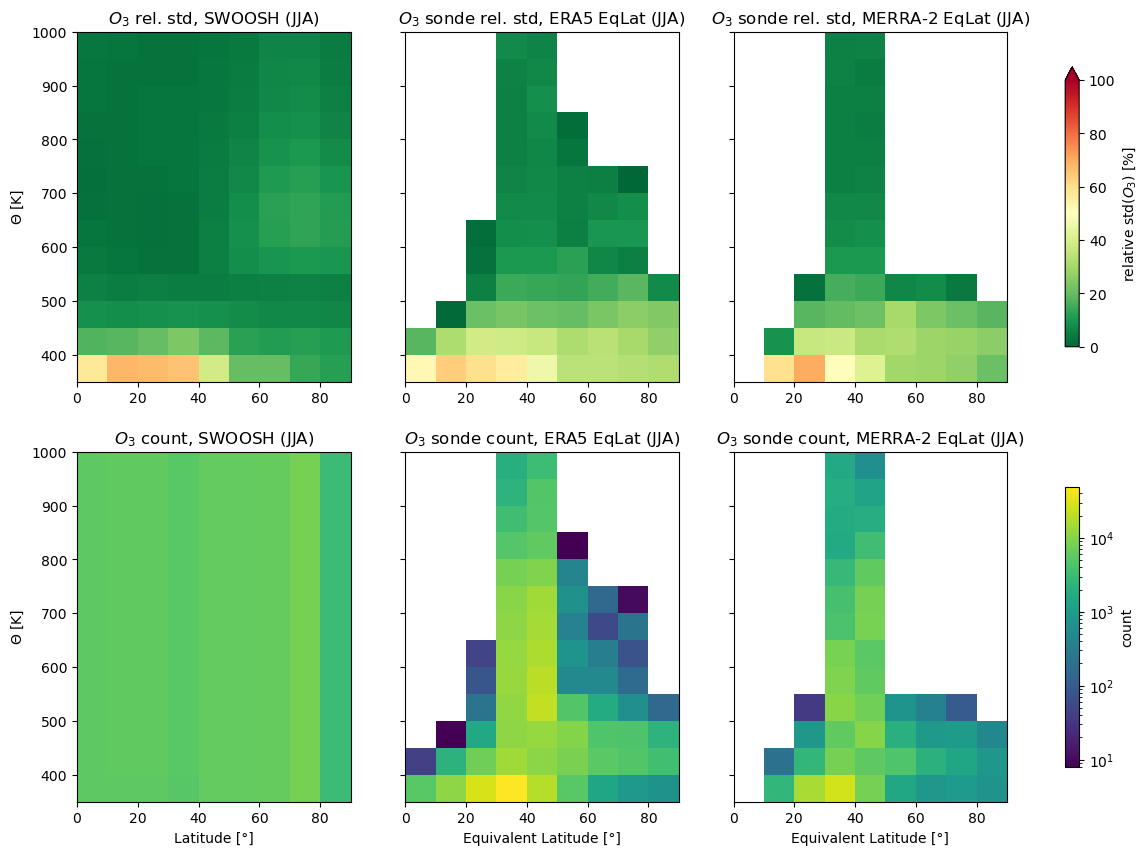

In [760]:
fig, axes = plot_swoosh_ozonesonde_std_count('JJA')